# PubMed PubMedTEB: Data Quality & Filtering Analysis

Examine the raw `pubmed_teb.parquet` (38.2M articles) and quantify how many rows
each candidate filter removes, so we can decide which filters to apply before building
benchmark datasets.

In [1]:
import duckdb
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", font_scale=1.1)
PARQUET = "/gpfs01/berens/data/data/pubmed_processed/pubmed_teb.parquet"
OUTPUTS = Path("outputs")
OUTPUTS.mkdir(exist_ok=True)

con = duckdb.connect()
total = con.execute(f"SELECT COUNT(*) FROM '{PARQUET}'").fetchone()[0]
print(f"Total rows: {total:,}")

Total rows: 38,201,553


## 1. Overall Data Profile

Quick look at null/empty rates and basic stats for every column.

In [2]:
profile = con.execute(f"""
    SELECT
        COUNT(*) AS total_rows,
        -- Text fields: null or empty
        SUM(CASE WHEN pmid IS NULL OR pmid = '' THEN 1 ELSE 0 END) AS pmid_missing,
        SUM(CASE WHEN title IS NULL OR title = '' THEN 1 ELSE 0 END) AS title_missing,
        SUM(CASE WHEN abstract_text IS NULL OR abstract_text = '' THEN 1 ELSE 0 END) AS abstract_missing,
        SUM(CASE WHEN journal IS NULL OR journal = '' THEN 1 ELSE 0 END) AS journal_missing,
        SUM(CASE WHEN language IS NULL OR language = '' THEN 1 ELSE 0 END) AS language_missing,
        SUM(CASE WHEN doi IS NULL OR doi = '' THEN 1 ELSE 0 END) AS doi_missing,
        SUM(CASE WHEN country IS NULL OR country = '' THEN 1 ELSE 0 END) AS country_missing,
        SUM(CASE WHEN semantic_category IS NULL OR semantic_category = '' THEN 1 ELSE 0 END) AS category_missing,
        -- Numeric / list fields
        SUM(CASE WHEN year = 0 THEN 1 ELSE 0 END) AS year_missing,
        SUM(CASE WHEN len(mesh_descriptors) = 0 THEN 1 ELSE 0 END) AS mesh_empty,
        SUM(CASE WHEN len(cited_pmids) = 0 THEN 1 ELSE 0 END) AS citations_empty,
        SUM(CASE WHEN len(publication_types) = 0 THEN 1 ELSE 0 END) AS pubtypes_empty,
        -- Duplicates
        COUNT(*) - COUNT(DISTINCT pmid) AS duplicate_pmids
    FROM '{PARQUET}'
""").fetchdf()

# Reshape for readability
cols = [c for c in profile.columns if c != "total_rows"]
rows = []
for c in cols:
    val = int(profile[c].iloc[0])
    rows.append({"check": c, "count": val, "pct": f"{val / total * 100:.1f}%"})

import pandas as pd
summary = pd.DataFrame(rows)
print(f"Total rows: {total:,}\n")
summary

Total rows: 38,201,553



,check,count,pct
0,pmid_missing,0,0.0%
1,title_missing,37219,0.1%
2,abstract_missing,11452541,30.0%
3,journal_missing,0,0.0%
4,language_missing,0,0.0%
5,doi_missing,8904376,23.3%
6,country_missing,351,0.0%
7,category_missing,6175733,16.2%
8,year_missing,16445,0.0%
9,mesh_empty,6175731,16.2%


## 2. Candidate Filters — Individual Impact

Evaluate each filter independently: how many rows does it remove?

In [3]:
filters = con.execute(f"""
    SELECT
        -- F1: Missing abstract
        SUM(CASE WHEN abstract_text IS NULL OR abstract_text = '' THEN 1 ELSE 0 END)
            AS f1_no_abstract,
        -- F2: Missing title
        SUM(CASE WHEN title IS NULL OR title = '' THEN 1 ELSE 0 END)
            AS f2_no_title,
        -- F3: Non-English
        SUM(CASE WHEN language != 'eng' THEN 1 ELSE 0 END)
            AS f3_non_english,
        -- F4: Missing or implausible year (0, or before 1800)
        SUM(CASE WHEN year < 1800 THEN 1 ELSE 0 END)
            AS f4_bad_year,
        -- F5: Very short abstracts (< 50 chars — likely stubs)
        SUM(CASE WHEN abstract_text IS NOT NULL AND abstract_text != ''
                  AND length(abstract_text) < 50 THEN 1 ELSE 0 END)
            AS f5_short_abstract,
        -- F6: Retracted or non-research publication types
        SUM(CASE WHEN list_contains(publication_types, 'Retracted Publication')
                   OR list_contains(publication_types, 'Published Erratum')
                   OR list_contains(publication_types, 'Comment')
                   OR list_contains(publication_types, 'Letter')
                   OR list_contains(publication_types, 'Editorial')
                   OR list_contains(publication_types, 'News')
            THEN 1 ELSE 0 END)
            AS f6_non_research,
        -- F7: Duplicate PMIDs
        COUNT(*) - COUNT(DISTINCT pmid) AS f7_duplicate_pmids,
        -- F8: No MeSH descriptors
        SUM(CASE WHEN len(mesh_descriptors) = 0 THEN 1 ELSE 0 END)
            AS f8_no_mesh,
        -- Total
        COUNT(*) AS total
    FROM '{PARQUET}'
""").fetchdf()

filter_names = {
    "f1_no_abstract": "Missing abstract",
    "f2_no_title": "Missing title",
    "f3_non_english": "Non-English",
    "f4_bad_year": "Year missing or < 1800",
    "f5_short_abstract": "Abstract < 50 chars",
    "f6_non_research": "Non-research pub type",
    "f7_duplicate_pmids": "Duplicate PMIDs",
    "f8_no_mesh": "No MeSH descriptors",
}

rows = []
for col, label in filter_names.items():
    val = int(filters[col].iloc[0])
    rows.append({"filter": label, "removed": f"{val:,}", "pct_of_total": f"{val / total * 100:.1f}%", "remaining": f"{total - val:,}"})

filter_df = pd.DataFrame(rows)
filter_df

,filter,removed,pct_of_total,remaining
0,Missing abstract,"11,452,541",30.0%,"26,749,012"
1,Missing title,"37,219",0.1%,"38,164,334"
2,Non-English,"4,876,576",12.8%,"33,324,977"
3,Year missing or < 1800,"17,357",0.0%,"38,184,196"
4,Abstract < 50 chars,"9,716",0.0%,"38,191,837"
5,Non-research pub type,"2,702,887",7.1%,"35,498,666"
6,Duplicate PMIDs,"3,864",0.0%,"38,197,689"
7,No MeSH descriptors,"6,175,731",16.2%,"32,025,822"


## 3. Deeper Dives

### 3a. Language Distribution

In [4]:
lang_df = con.execute(f"""
    SELECT language, COUNT(*) AS cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM '{PARQUET}'
    GROUP BY language
    ORDER BY cnt DESC
    LIMIT 20
""").fetchdf()
lang_df

,language,cnt,pct
0,eng,33324977,87.2
1,ger,903996,2.4
2,fre,757181,2.0
3,rus,702834,1.8
4,jpn,437938,1.1
5,chi,372298,1.0
6,spa,347427,0.9
7,ita,303106,0.8
8,und,238470,0.6
9,pol,171800,0.4


### 3b. Year Distribution & Outliers

In [5]:
# Year extremes
year_extremes = con.execute(f"""
    SELECT
        MIN(year) AS min_year, MAX(year) AS max_year,
        SUM(CASE WHEN year = 0 THEN 1 ELSE 0 END) AS year_zero,
        SUM(CASE WHEN year > 0 AND year < 1900 THEN 1 ELSE 0 END) AS before_1900,
        SUM(CASE WHEN year > 2026 THEN 1 ELSE 0 END) AS after_2026,
        PERCENTILE_CONT(0.01) WITHIN GROUP (ORDER BY year) FILTER (year > 0) AS p1,
        PERCENTILE_CONT(0.99) WITHIN GROUP (ORDER BY year) FILTER (year > 0) AS p99
    FROM '{PARQUET}'
""").fetchdf()
year_extremes

,min_year,max_year,year_zero,before_1900,after_2026,p1,p99
0,0,3276,16445.0,164776.0,3.0,1943.0,2024.0


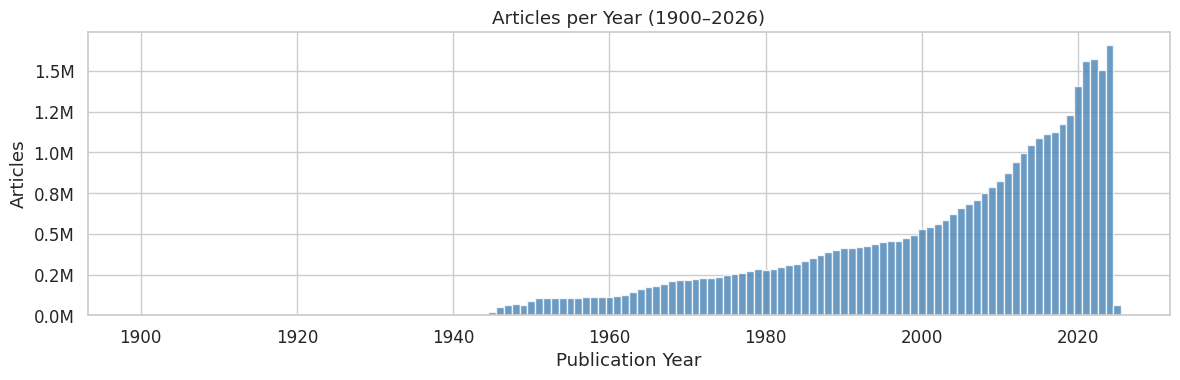

In [6]:
# Year histogram (valid years only)
year_hist = con.execute(f"""
    SELECT year, COUNT(*) AS cnt
    FROM '{PARQUET}'
    WHERE year BETWEEN 1900 AND 2026
    GROUP BY year ORDER BY year
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(year_hist["year"], year_hist["cnt"], width=1, color="steelblue", alpha=0.8)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Articles")
ax.set_title("Articles per Year (1900–2026)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

### 3c. Publication Types Breakdown

In [7]:
# Unnest publication_types and count
pubtype_df = con.execute(f"""
    SELECT pub_type, COUNT(*) AS cnt
    FROM '{PARQUET}', UNNEST(publication_types) AS t(pub_type)
    GROUP BY pub_type
    ORDER BY cnt DESC
    LIMIT 25
""").fetchdf()
pubtype_df["pct"] = (pubtype_df["cnt"] / total * 100).round(1)
pubtype_df

,pub_type,cnt,pct
0,Journal Article,35707358,93.5
1,"Research Support, Non-U.S. Gov't",8686635,22.7
2,Review,3406883,8.9
3,Case Reports,2454473,6.4
4,Comparative Study,1936953,5.1
5,English Abstract,1516571,4.0
6,"Research Support, U.S. Gov't, P.H.S.",1486653,3.9
7,"Research Support, N.I.H., Extramural",1460974,3.8
8,Letter,1282244,3.4
9,Comment,1045953,2.7


### 3d. Abstract Length Distribution

In [8]:
# Abstract length stats (non-empty only)
abs_stats = con.execute(f"""
    SELECT
        COUNT(*) AS n,
        ROUND(AVG(length(abstract_text))) AS mean_chars,
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY length(abstract_text)) AS median_chars,
        MIN(length(abstract_text)) AS min_chars,
        MAX(length(abstract_text)) AS max_chars,
        SUM(CASE WHEN length(abstract_text) < 50 THEN 1 ELSE 0 END) AS under_50,
        SUM(CASE WHEN length(abstract_text) < 100 THEN 1 ELSE 0 END) AS under_100,
        SUM(CASE WHEN length(abstract_text) BETWEEN 100 AND 500 THEN 1 ELSE 0 END) AS short_100_500,
        SUM(CASE WHEN length(abstract_text) > 5000 THEN 1 ELSE 0 END) AS over_5000
    FROM '{PARQUET}'
    WHERE abstract_text IS NOT NULL AND abstract_text != ''
""").fetchdf()
abs_stats

,n,mean_chars,median_chars,min_chars,max_chars,under_50,under_100,short_100_500,over_5000
0,26749012,1341.0,1351.0,1,94662,9716.0,69050.0,1505155.0,8387.0


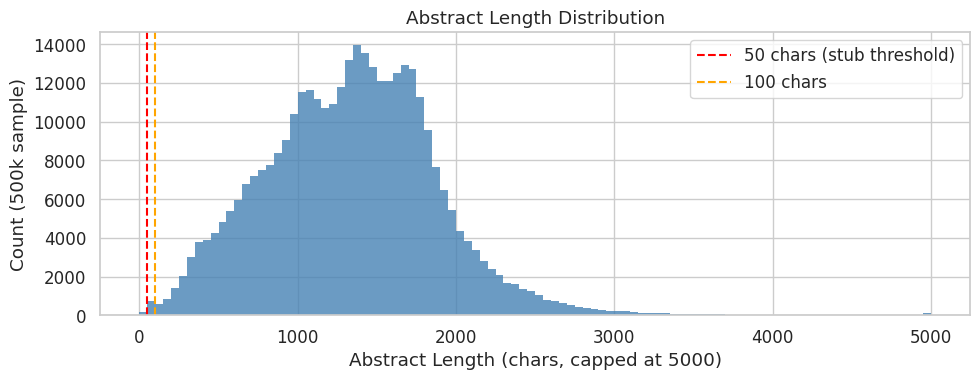

In [9]:
# Histogram of abstract lengths 
abs_len = con.execute(f"""
    SELECT LEAST(length(abstract_text), 5000) AS abs_len
    FROM '{PARQUET}'
    WHERE abstract_text IS NOT NULL AND abstract_text != ''
    USING SAMPLE 500000
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(abs_len["abs_len"], bins=100, color="steelblue", alpha=0.8, edgecolor="none")
ax.axvline(50, color="red", ls="--", label="50 chars (stub threshold)")
ax.axvline(100, color="orange", ls="--", label="100 chars")
ax.set_xlabel("Abstract Length (chars, capped at 5000)")
ax.set_ylabel("Count (500k sample)")
ax.set_title("Abstract Length Distribution")
ax.legend()
plt.tight_layout()
plt.show()

### 3e. Sample: Very Short Abstracts

What do abstracts under 150 characters look like?

In [25]:
short_abs = con.execute(f"""
    SELECT pmid, title, abstract_text, language, year,
           length(abstract_text) AS abs_len
    FROM '{PARQUET}'
    WHERE abstract_text IS NOT NULL AND abstract_text != ''
          AND length(abstract_text) <= 150
    USING SAMPLE 20
""").fetchdf()
short_abs

,pmid,title,abstract_text,language,year,abs_len


### 3f. Filter Overlap — How Many Are Hit by Multiple Filters?

In [21]:
# Count how many filters each row triggers 
overlap = con.execute(f"""
    SELECT n_filters, COUNT(*) AS cnt,
           ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct
    FROM (
        SELECT
            (CASE WHEN abstract_text IS NULL OR abstract_text = '' THEN 1 ELSE 0 END)
            + (CASE WHEN title IS NULL OR title = '' THEN 1 ELSE 0 END)
            + (CASE WHEN language != 'eng' THEN 1 ELSE 0 END)
            + (CASE WHEN year < 1800 THEN 1 ELSE 0 END)
            + (CASE WHEN abstract_text IS NOT NULL AND abstract_text != ''
                    AND length(abstract_text) < 50 THEN 1 ELSE 0 END)
            + (CASE WHEN list_contains(publication_types, 'Retracted Publication')
                     OR list_contains(publication_types, 'Published Erratum')
                     OR list_contains(publication_types, 'Comment')
                     OR list_contains(publication_types, 'Letter')
                     OR list_contains(publication_types, 'Editorial')
                     OR list_contains(publication_types, 'News')
              THEN 1 ELSE 0 END)
            AS n_filters
        FROM '{PARQUET}'
    )
    GROUP BY n_filters
    ORDER BY n_filters
""").fetchdf()
overlap

,n_filters,cnt,pct
0,0,24877098,65.1
1,1,7751246,20.3
2,2,5386230,14.1
3,3,175326,0.5
4,4,11653,0.0


## 4. Combined Filter — Final Dataset Size

Apply all recommended filters together and see what remains.

In [26]:
# Apply all filters combined
combined = con.execute(f"""
    SELECT COUNT(*) AS remaining
    FROM '{PARQUET}'
    WHERE
        -- Has abstract
        abstract_text IS NOT NULL AND abstract_text != ''
        -- Has title
        AND title IS NOT NULL AND title != ''
        -- English only
        AND language = 'eng'
        -- Valid year
        AND year >= 1970
        -- Not a stub abstract
        AND length(abstract_text) >= 150
        -- Research articles (exclude retractions, errata, comments, etc.)
        AND NOT (
            list_contains(publication_types, 'Retracted Publication')
            OR list_contains(publication_types, 'Published Erratum')
            OR list_contains(publication_types, 'Comment')
            OR list_contains(publication_types, 'Letter')
            OR list_contains(publication_types, 'Editorial')
            OR list_contains(publication_types, 'News')
        )
""").fetchone()[0]

removed = total - combined
print(f"Before filtering:  {total:>12,}")
print(f"After filtering:   {combined:>12,}")
print(f"Removed:           {removed:>12,} ({removed / total * 100:.1f}%)")
print(f"Retained:          {combined / total * 100:.1f}%")

Before filtering:    38,201,553
After filtering:     24,780,714
Removed:             13,420,839 (35.1%)
Retained:          64.9%


## 5. Filtered Dataset — Quick Profile

Verify the filtered dataset looks healthy.

In [27]:
FILTER_CLAUSE = """
    abstract_text IS NOT NULL AND abstract_text != ''
    AND title IS NOT NULL AND title != ''
    AND language = 'eng'
    AND year >= 1970
    AND length(abstract_text) >= 150
    AND NOT (
        list_contains(publication_types, 'Retracted Publication')
        OR list_contains(publication_types, 'Published Erratum')
        OR list_contains(publication_types, 'Comment')
        OR list_contains(publication_types, 'Letter')
        OR list_contains(publication_types, 'Editorial')
        OR list_contains(publication_types, 'News')
    )
"""

post_filter = con.execute(f"""
    SELECT
        COUNT(*) AS total,
        MIN(year) AS min_year, MAX(year) AS max_year,
        ROUND(AVG(length(abstract_text))) AS mean_abs_len,
        ROUND(PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY length(abstract_text))) AS median_abs_len,
        SUM(CASE WHEN len(mesh_descriptors) > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS mesh_pct,
        SUM(CASE WHEN len(cited_pmids) > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS cite_pct,
        SUM(CASE WHEN doi IS NOT NULL AND doi != '' THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS doi_pct,
        COUNT(DISTINCT semantic_category) AS n_categories
    FROM '{PARQUET}'
    WHERE {FILTER_CLAUSE}
""").fetchdf()
post_filter

,total,min_year,max_year,mean_abs_len,median_abs_len,mesh_pct,cite_pct,doi_pct,n_categories
0,24780714,1970,3276,1367.0,1375.0,81.309271,36.911963,92.340632,16


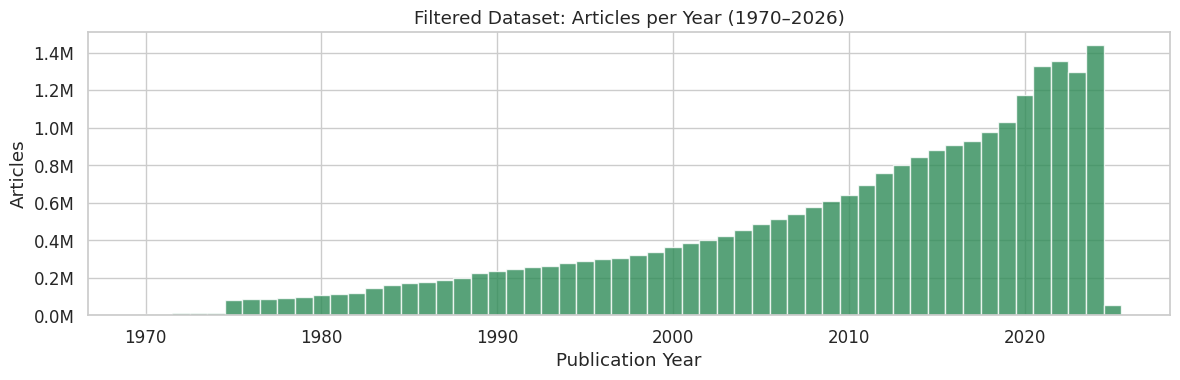

In [29]:
# Year distribution after filtering
year_filtered = con.execute(f"""
    SELECT year, COUNT(*) AS cnt
    FROM '{PARQUET}'
    WHERE {FILTER_CLAUSE} AND year BETWEEN 1970 AND 2026
    GROUP BY year ORDER BY year
""").fetchdf()

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(year_filtered["year"], year_filtered["cnt"], width=1, color="seagreen", alpha=0.8)
ax.set_xlabel("Publication Year")
ax.set_ylabel("Articles")
ax.set_title("Filtered Dataset: Articles per Year (1970–2026)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

## 6. Semantic Category Distribution (Filtered)

Check MeSH category balance after filtering.

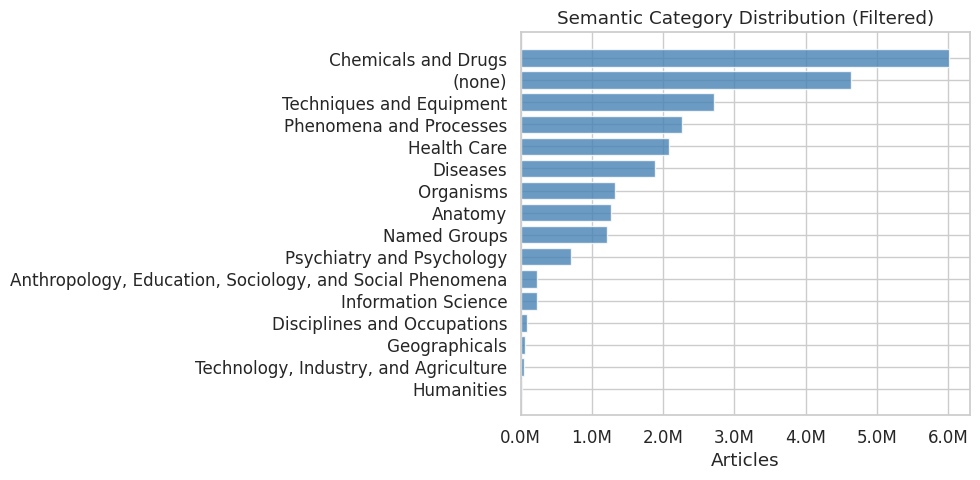

In [30]:
cat_df = con.execute(f"""
    SELECT
        CASE WHEN semantic_category = '' THEN '(none)' ELSE semantic_category END AS category,
        COUNT(*) AS cnt
    FROM '{PARQUET}'
    WHERE {FILTER_CLAUSE}
    GROUP BY category
    ORDER BY cnt DESC
""").fetchdf()

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(cat_df["category"][::-1], cat_df["cnt"][::-1], color="steelblue", alpha=0.8)
ax.set_xlabel("Articles")
ax.set_title("Semantic Category Distribution (Filtered)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
plt.tight_layout()
plt.show()

## 7. Summary

| Filter | Rationale |
|--------|-----------|
| **Has abstract** | Embedding benchmarks need text to embed |
| **Has title** | Required for title-abstract pair tasks (retrieval, STS) |
| **English only** | Consistent evaluation; most embedding models are English-first |
| **Year >= 1970** | Removes missing years and pre-modern articles with limited metadata |
| **Abstract >= 150 chars** | Removes stubs and placeholder abstracts |
| **Exclude non-research types** | Retractions, errata, comments, letters, editorials, and news are not research articles |

Filters **not** applied (but available if needed downstream):
- **No MeSH descriptors**: ~16% of articles lack MeSH; only needed for MeSH-based tasks
- **No citations**: ~73% lack citations; only needed for citation prediction tasks
- **No DOI**: ~23% lack DOI; not needed for any benchmark task

## 8. Apply Filters & Write Output

Materialize the filtered dataset as a new Parquet file for downstream benchmark construction.

In [31]:
OUTPUT_PARQUET = "/gpfs01/berens/data/data/pubmed_processed/pubmed_teb_filtered.parquet"

con.execute(f"""
    COPY (
        SELECT *
        FROM '{PARQUET}'
        WHERE {FILTER_CLAUSE}
    ) TO '{OUTPUT_PARQUET}' (FORMAT PARQUET, COMPRESSION ZSTD)
""")

filtered_count = con.execute(f"SELECT COUNT(*) FROM '{OUTPUT_PARQUET}'").fetchone()[0]
print(f"Filtered Parquet written to: {OUTPUT_PARQUET}")
print(f"Rows: {filtered_count:,}")
print(f"Retained: {filtered_count / total * 100:.1f}% of original {total:,}")

Filtered Parquet written to: /gpfs01/berens/data/data/pubmed_processed/pubmed_teb_filtered.parquet
Rows: 24,780,714
Retained: 64.9% of original 38,201,553


In [32]:
# Sanity check the filtered output
verify = con.execute(f"""
    SELECT
        COUNT(*) AS total,
        COUNT(DISTINCT pmid) AS unique_pmids,
        MIN(year) AS min_year,
        MAX(year) AS max_year,
        MIN(length(abstract_text)) AS min_abs_len,
        ROUND(AVG(length(abstract_text))) AS mean_abs_len,
        SUM(CASE WHEN language != 'eng' THEN 1 ELSE 0 END) AS non_english,
        SUM(CASE WHEN len(mesh_descriptors) > 0 THEN 1 ELSE 0 END) * 100.0 / COUNT(*) AS mesh_pct
    FROM '{OUTPUT_PARQUET}'
""").fetchdf()
verify

,total,unique_pmids,min_year,max_year,min_abs_len,mean_abs_len,non_english,mesh_pct
0,24780714,24776878,1970,3276,150,1367.0,0.0,81.309271
